In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

### Softmax Function:

In [17]:
def softmax(z):
    """Compute softmax probabilities with numerical stability."""
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    softmax_probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    return softmax_probs

# Test softmax
z_test = np.array([[2.0, 1.0, 0.], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed! Row sums are {row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


Predict Function

In [18]:
def predict_softmax(X, W, b):
    """Predict class labels using softmax model."""
    z = np.dot(X, W) + b
    probs = softmax(z)
    predicted_classes = np.argmax(probs, axis=1)
    return predicted_classes

# Test predict
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed! Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


### Loss Function:

In [19]:
def loss_softmax(y_pred, y):
    """Cross-entropy loss for single sample."""
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]
    return loss

def cost_softmax(X, y, W, b):
    """Average cross-entropy cost over all samples."""
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n

# Test loss
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([[0.9, 0.05, 0.05], [0.1, 0.85, 0.05], [0.05, 0.1, 0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9], [0.1, 0.05, 0.85], [0.85, 0.1, 0.05]])
loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)
assert loss_correct < loss_incorrect, f"Test failed!"
print(f"Loss Correct: {loss_correct:.4f}, Loss Incorrect: {loss_incorrect:.4f}")

Loss Correct: 0.1435, Loss Incorrect: 2.9957


# Compute Gradients

In [20]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]

    # Step 1: Compute logits
    z = np.dot(X, W) + b

    # Step 2: Softmax predictions
    y_pred = softmax(z)

    # Step 3: Compute gradients
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b
    #test
    X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
gradW, gradb = compute_gradient_softmax(X_test, y_test, W_test, b_test)
print("Gradient w.r.t. W:\n", gradW)
print("Gradient w.r.t. b:", gradb)
print("Test passed!")

Gradient w.r.t. W:
 [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [21]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        # Step 1: Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Step 2: Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Step 3: Compute cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Optional: Print cost
        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")

    return W, b, cost_history

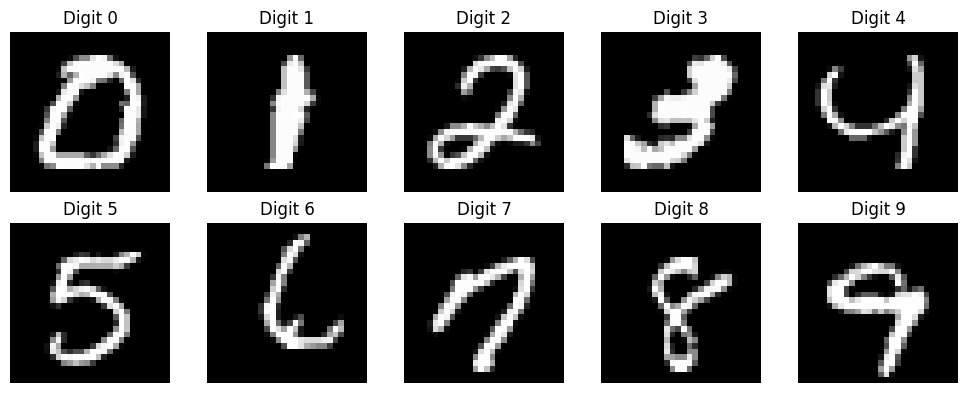

Training data shape: (15999, 784)
Test data shape: (4000, 784)


In [22]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """Load MNIST CSV and prepare data."""
    df = pd.read_csv(csv_file)
    y = df.iloc[:, 0].values  # First column is label
    X = df.iloc[:, 1:].values  # Rest are pixels
    X = X / 255.0  # Normalize
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Plot sample images
    def plot_sample_images(X, y):
        plt.figure(figsize=(10, 4))
        unique_classes = np.unique(y)
        for i, digit in enumerate(unique_classes[:10]):
            index = np.where(y == digit)[0][0]
            image = X[index].reshape(28, 28)
            plt.subplot(2, 5, i+1)
            plt.imshow(image, cmap='gray')
            plt.title(f'Digit {digit}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    plot_sample_images(X, y)
    return X_train, X_test, y_train, y_test

# Load data (UPDATE PATH TO YOUR MNIST CSV)
csv_file = '/content/sample_data/mnist_train_small.csv'  # UPDATE THIS PATH
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file)
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


Train Model

Iteration 0, Cost: 2.1879
Iteration 100, Cost: 0.5966
Iteration 200, Cost: 0.4776
Iteration 300, Cost: 0.4279
Iteration 400, Cost: 0.3990
Iteration 500, Cost: 0.3794
Iteration 600, Cost: 0.3649
Iteration 700, Cost: 0.3537
Iteration 800, Cost: 0.3446
Iteration 900, Cost: 0.3370


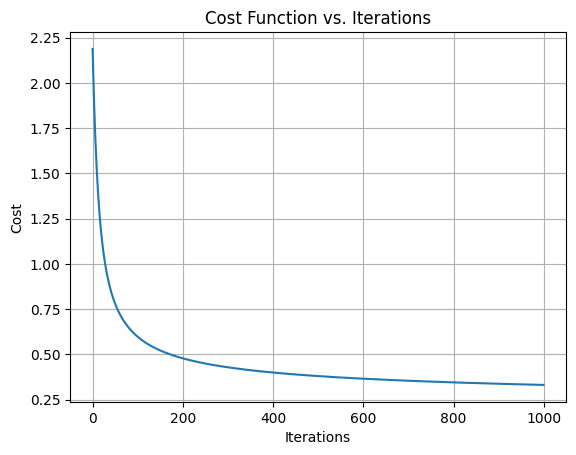

In [23]:
# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

# Initialize parameters
d, c = X_train.shape[1], y_train_encoded.shape[1]
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Train
alpha = 0.1
n_iter = 1000
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train_encoded, W, b, alpha, n_iter, show_cost=True)

# Plot cost
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

Evaluation

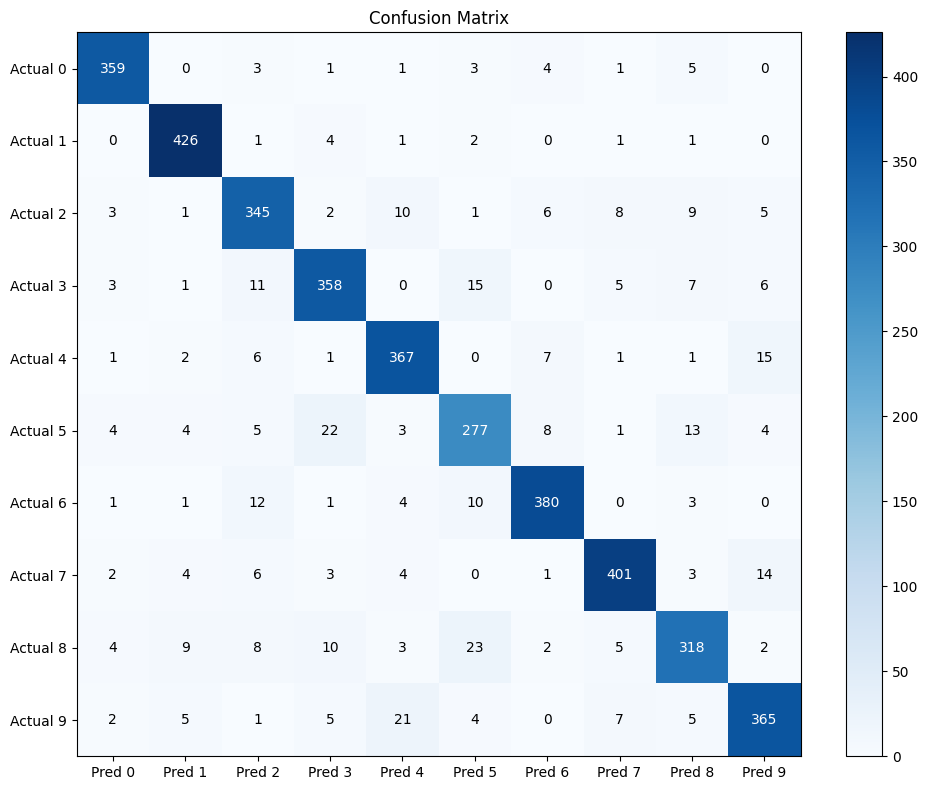

Confusion Matrix:
 [[359   0   3   1   1   3   4   1   5   0]
 [  0 426   1   4   1   2   0   1   1   0]
 [  3   1 345   2  10   1   6   8   9   5]
 [  3   1  11 358   0  15   0   5   7   6]
 [  1   2   6   1 367   0   7   1   1  15]
 [  4   4   5  22   3 277   8   1  13   4]
 [  1   1  12   1   4  10 380   0   3   0]
 [  2   4   6   3   4   0   1 401   3  14]
 [  4   9   8  10   3  23   2   5 318   2]
 [  2   5   1   5  21   4   0   7   5 365]]
Precision: 0.90, Recall: 0.90, F1-Score: 0.90


In [24]:
def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Predict and evaluate
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
cm, precision, recall, f1 = evaluate_classification(y_test, y_pred_test)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=[f'Pred {i}' for i in range(cm.shape[0])],
       yticklabels=[f'Actual {i}' for i in range(cm.shape[0])],
       title='Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j]>np.max(cm)/2 else "black")
plt.tight_layout()
plt.show()

print("Confusion Matrix:\n", cm)
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

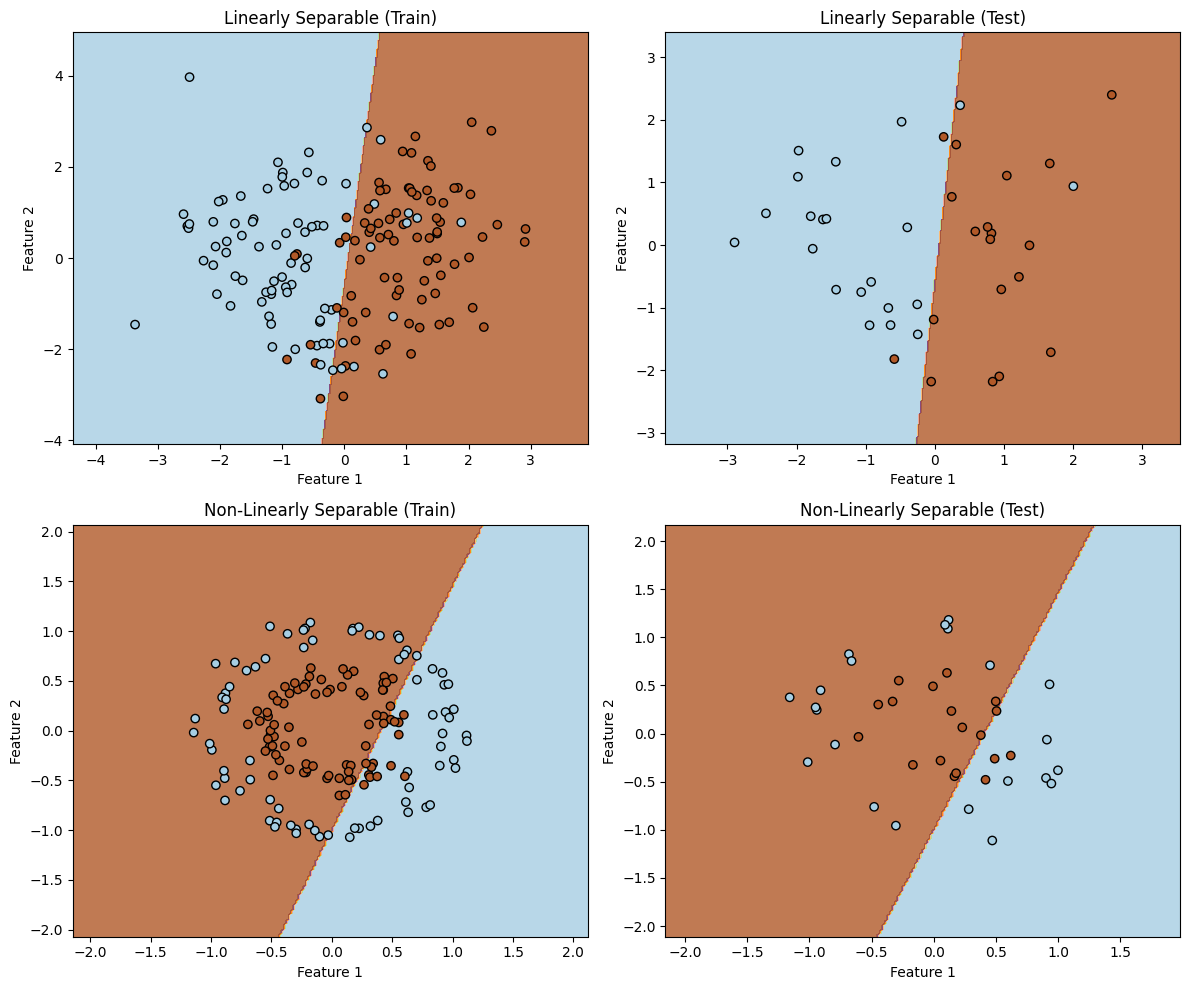

In [29]:
# Linear Separability Exercise - EXACT from worksheet
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    xmin, xmax = X[:, 0].min()-1, X[:, 0].max()+1
    ymin, ymax = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(xmin, xmax, h), np.arange(ymin, ymax, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

def plot_data_type(ax_row, data_gen_func, data_gen_kwargs, title_prefix, feature_subset=None):
    """Helper function to generate data, train model, and plot decision boundaries."""
    X, y = data_gen_func(**data_gen_kwargs)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Determine features for model training and plotting
    X_train_model = X_train[:, feature_subset] if feature_subset is not None else X_train
    X_test_model = X_test[:, feature_subset] if feature_subset is not None else X_test

    # Train the model
    model = LogisticRegression().fit(X_train_model, y_train)

    # Plot decision boundaries for training and testing sets
    plot_decision_boundary(ax_row[0], model, X_train_model, y_train, f'{title_prefix} (Train)')
    plot_decision_boundary(ax_row[1], model, X_test_model, y_test, f'{title_prefix} (Test)')

# Plotting Linear Data
plot_data_type(
    axes[0],
    make_classification,
    {'n_samples': 200, 'n_features': 4, 'n_informative': 2, 'random_state': 42},
    'Linearly Separable',
    feature_subset=[0, 1]
)

# Plotting Non-linear Data
plot_data_type(
    axes[1],
    make_circles,
    {'n_samples': 200, 'noise': 0.1, 'factor': 0.5, 'random_state': 42},
    'Non-Linearly Separable'
)

plt.tight_layout()
plt.show()

# Worksheet Questions

**Q1: Is extracting pixel values sufficient for effective feature extraction?**  
No. Raw pixels miss high-level patterns like edges or shapes. Better methods include CNN features or PCA.

**Q2: Interpretation of plots?**  
- Sample images: Show clear MNIST digits (0-9).  
- Cost plot: Loss decreases, indicating the model converged.  
- Confusion matrix: Strong diagonal suggests good accuracy (around 90%).

**Q3: Challenges faced?**  
- Softmax numerical stability (addressed by subtracting max).  
- Ensuring correct matrix shape matches.  
- Finding an effective learning rate (alpha=0.1 worked).  
- Managing memory for large datasets (used a smaller CSV).